# 2.3. Perform nested regression with bootstrapping of metric value against magnitude of ablation and biological covariate confluence

Assesses how each metrics is able to capture the variation in ablation magnitude while
being unbiased across biological covariates.

In [1]:
import pathlib
import yaml
import ast

import pandas as pd
import polars as pl

from image_ablation_analysis.indexing import ParquetIndex
from image_ablation_analysis.regression.nested_regression import (
    bootstrap_nested_regression,
    BootstrapConfig,
    ColumnSpec,
)
from image_ablation_analysis.regression.visualization import plot_partial_r2_vs_r2

## Pathing

In [2]:
module_config_path = pathlib.Path("..") / '2.metrics_ablation_analysis' / 'config.yml'
if not module_config_path.exists():
    raise FileNotFoundError(f"Module config file not found: {module_config_path}")
config = yaml.safe_load(module_config_path.read_text())
results_dir = pathlib.Path(".") / "results"
results_dir.mkdir(exist_ok=True) 

abl_root = pathlib.Path(config['ablation_output_path']).resolve(strict=True)

metrics_dir = abl_root / "results" / "metrics"
if not metrics_dir.exists():
    raise FileNotFoundError(f"Metrics directory not found: {metrics_dir}")

## Read in the raw metric evaluation result
Has the metric name, metric value plus filepaths to the pair of ablated images and its raw reference

In [3]:
# Load lazy here and only display schema and head to confirm the structure
lf = pl.scan_parquet(str(metrics_dir / '*.parquet'), parallel="columns")
print(lf.collect_schema().names())
print(lf.head())

['variant', 'original_abs_path', 'aug_abs_path', 'metric_name', 'metric_value']
naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

SLICE[offset: 0, len: 5]
  Parquet SCAN [/mnt/hdd20tb/alsf_ablation/results/metrics/metrics_000000.parquet, ... 290492 other sources]
  PROJECT */5 COLUMNS
  ESTIMATED ROWS: 16267608


## Shared boostrap/regression parameters
All regression analysis will share the same dependent variable, whichare the metric values as well as the first (restricted) independent variable which will be the parameter value. The full independent variable and the groupings of regression analysis will change based on the confounding variable being tested for.

In [4]:
regression_config = {
    "y": "metric_value",    # dependent variable, always metric value for this analysis
    "x1": "param_values",   # independent variable 1, always the ablation parameter values for this analysis
}

bootstrap_config = {
    "n_boot": 300,
    "sample_frac": 0.5,
    "replace": True,
    "standardize": False,
    "robust_cov": None,     # or "HC3"
    "min_group_size": 25,   # prevent regression on tiny groups
}

visualization_config = {
    "hue_col": "metric_name",
    "partial_col": "partial_r2_x2",
    "r2_col": "r2_restricted",
    "partial_label": "Partial R² (confluence)",
    "r2_label": "R² Restricted (higher is better)",
}

## Read in the ablation index & some wrangling
Contains ablation magnitude and type metadata needing for regression

In [5]:

def wrangle_data_for_regression(df: pd.DataFrame) -> pd.DataFrame:
    """
    Post pandas materialization data wrangling helper
    """
    
    df['param_values'] = df['param_values'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    df['param_values'] = df['param_values'].apply(lambda x: x[0] if isinstance(x, (list, tuple)) and len(x) == 1 else x)
    df['param_swept'] = df['param_swept'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    df['param_swept'] = df['param_swept'].apply(lambda x: x[0] if isinstance(x, (list, tuple)) and len(x) == 1 else x)
    
    return df

In [6]:
index = ParquetIndex(index_dir=abl_root / "ablated_index")
index_lf = index.read_lazy()

# Extract ablation package, type, and hash from config_id
# should be doable in lazy whereas those that require literal_eval or ast parsing should be done post materialization
index_lf = index_lf.with_columns(
    pl.col("config_id").str.split_exact(":", 2).alias("config_parts")
).with_columns(
    pl.col("config_parts").struct.field("field_0").alias("ablation_package"),
    pl.col("config_parts").struct.field("field_1").alias("ablation_type"),
    pl.col("config_parts").struct.field("field_2").alias("hash"),
).drop("config_parts")

print(lf.collect_schema().names())
print(lf.head())

['variant', 'original_abs_path', 'aug_abs_path', 'metric_name', 'metric_value']
naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

SLICE[offset: 0, len: 5]
  Parquet SCAN [/mnt/hdd20tb/alsf_ablation/results/metrics/metrics_000000.parquet, ... 290492 other sources]
  PROJECT */5 COLUMNS
  ESTIMATED ROWS: 16267608


## Merge metric eval output dataframe with ablation to produce dataframe for regression analysis

In [7]:
for_regression_lf = index_lf.join(
    lf,
    on=["original_abs_path", "aug_abs_path", "variant"],
    how="inner",
)

# technically the materialization could be delayed further until after the
# per condition filtering but since most of the regressions here
# share large overlaps in rows materialized and the full materialization is not too large,
# materilizing here avoids large time penalties of repeated materialization
for_regression = for_regression_lf.collect().to_pandas()
for_regression = wrangle_data_for_regression(for_regression)
print(len(for_regression))

17042256


In [8]:
# All cell lines in plate 1 and plate 2 for the cross cell line regression analysis
for_regression_plate1 = for_regression[for_regression['platemap_file'] == 'Assay_Plate1_platemap']
print(f"Number of samples in plate1: {len(for_regression_plate1)}")

for_regression_plate2 = for_regression[for_regression['platemap_file'] == 'Assay_Plate2_platemap']
print(f"Number of samples in plate2: {len(for_regression_plate2)}")

Number of samples in plate1: 10431960
Number of samples in plate2: 6610296


## Regression Analysis 1: Plate 1 U2-OS cell line, detecting how biased each metric is against confluence

In [9]:
# Only U2-OS cell line from plate 1
for_regression_plate1_u2os = for_regression_plate1[for_regression_plate1['cell_line'] == 'U2-OS']
print(f"Number of samples in plate1 U2-OS: {len(for_regression_plate1_u2os)}")

Number of samples in plate1 U2-OS: 742896


In [10]:
colspec = ColumnSpec(
    group_cols=("metric_name", "cell_line", "ablation_type"),
    x2="seeding_density", # full regression parameters
    x2_categorical=False,
    standardize_cols=("param_values", "seeding_density"),
    **regression_config
)

cfg = BootstrapConfig(
    **bootstrap_config
)

boot_res = bootstrap_nested_regression(for_regression_plate1_u2os, colspec, cfg)
boot_res.to_csv(results_dir / "boot_res_plate1_u2os_nest_confluence.csv", index=False)

Bootstrap groups:   0%|          | 0/42 [00:00<?, ?it/s]

### Visualize

Dotted curves here indicate thresholds comparing partial r^2 to restricted r^2:
1. On red or above: confounder explains ≥100% of restricted variance (quite bad)
2. On yellow or above: confounder explains ≥50% of restricted variance (meh)
3. On green or above: confounder explains ≥10% of restricted variance (better)
4. Below green: confounder explains <10% of restricted variance

Interpretation:
If two metrics fall on the same threshold curve, generally the one to the right is better (equal bias burden but more sensitive).
If two metrics are on the same x, the one with lower y is better.
In general, the most bottom right one would be the best.  

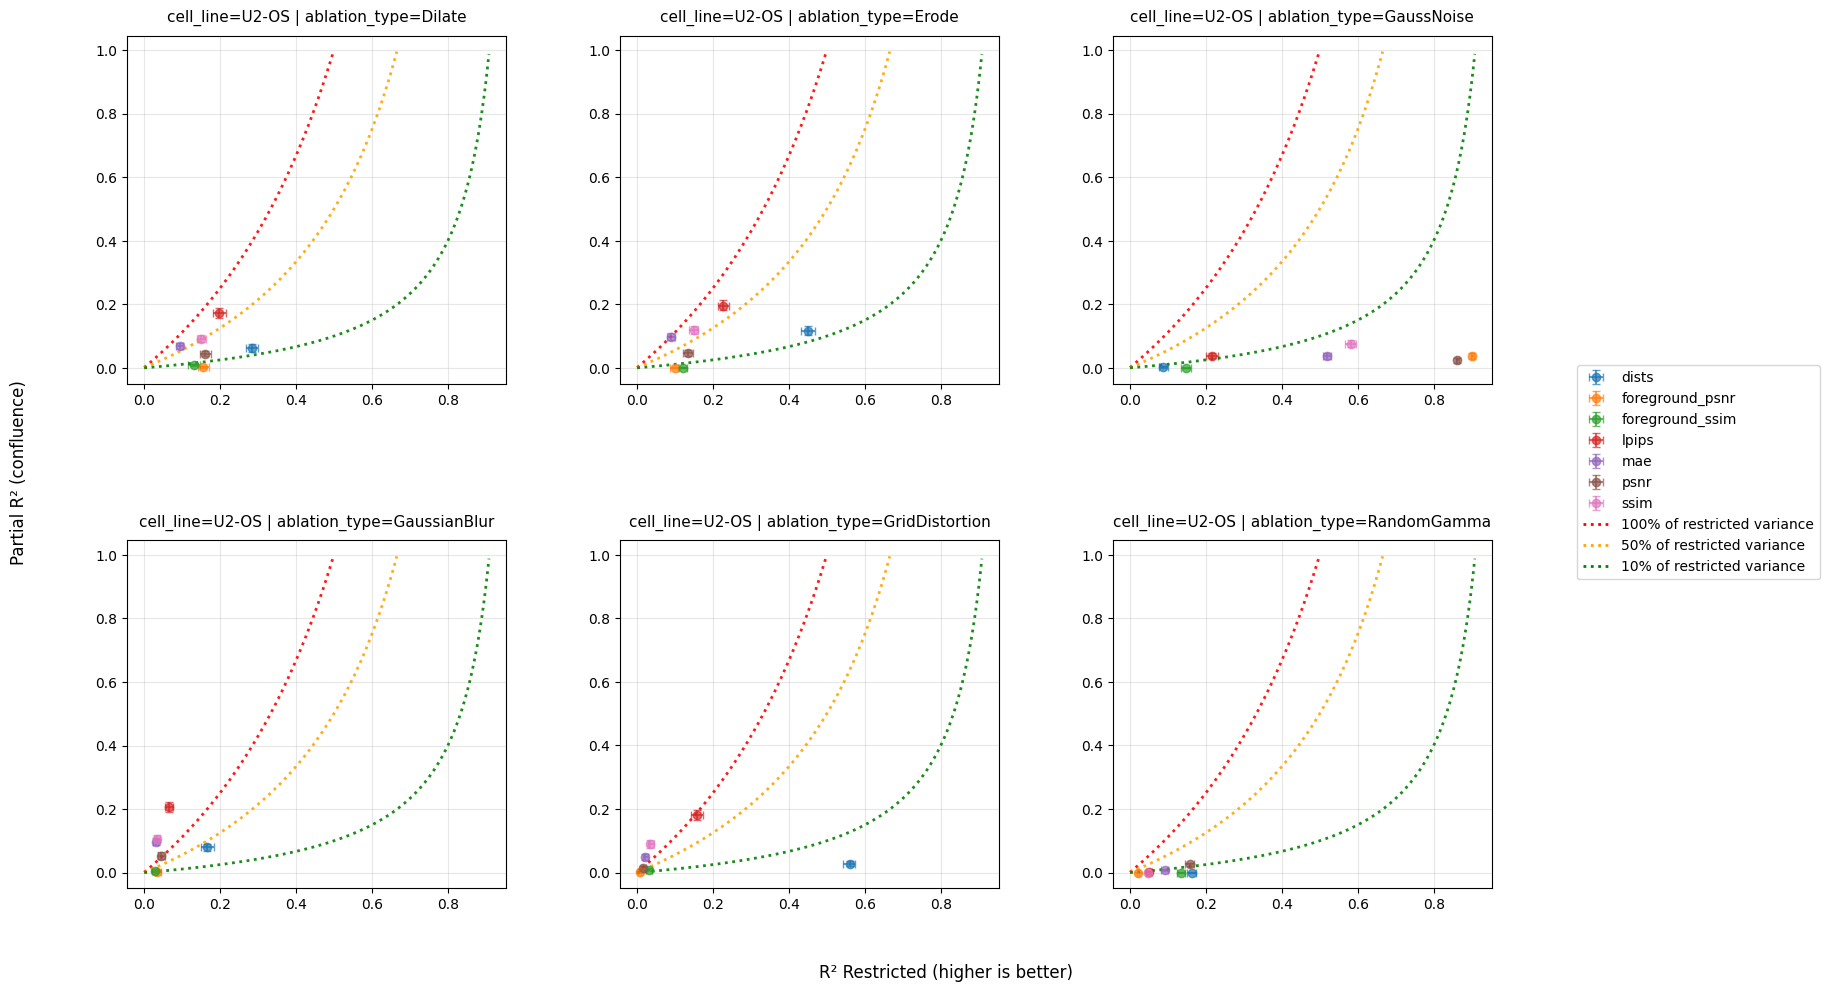

In [11]:
plot_partial_r2_vs_r2(
    boot_res=boot_res,
    panel_cols=["cell_line", "ablation_type"], 
    save_path=pathlib.Path("plots/plate1_u2os_nest_confluence.png"),
    show=True,
    **visualization_config
)

## Regression Analysis 2: Plate 2 U2-OS cell line, detecting how biased each metric is against confluence
Really just a plate 2 replicate of regression 1

In [12]:
# Only U2-OS cell line from plate 2
for_regression_plate2_u2os = for_regression_plate2[for_regression_plate2['cell_line'] == 'U2-OS']
print(f"Number of samples in plate2 U2-OS: {len(for_regression_plate2_u2os)}")

Number of samples in plate2 U2-OS: 988680


In [13]:
colspec = ColumnSpec(
    group_cols=("metric_name", "cell_line", "ablation_type"),
    x2="seeding_density", # full regression parameters
    x2_categorical=False,
    standardize_cols=("param_values", "seeding_density"),
    **regression_config
)

cfg = BootstrapConfig(
    **bootstrap_config
)

boot_res = bootstrap_nested_regression(for_regression_plate2_u2os, colspec, cfg)
boot_res.to_csv(results_dir / "boot_res_plate2_u2os_nest_confluence.csv", index=False)

Bootstrap groups:   0%|          | 0/42 [00:00<?, ?it/s]

### Visualize

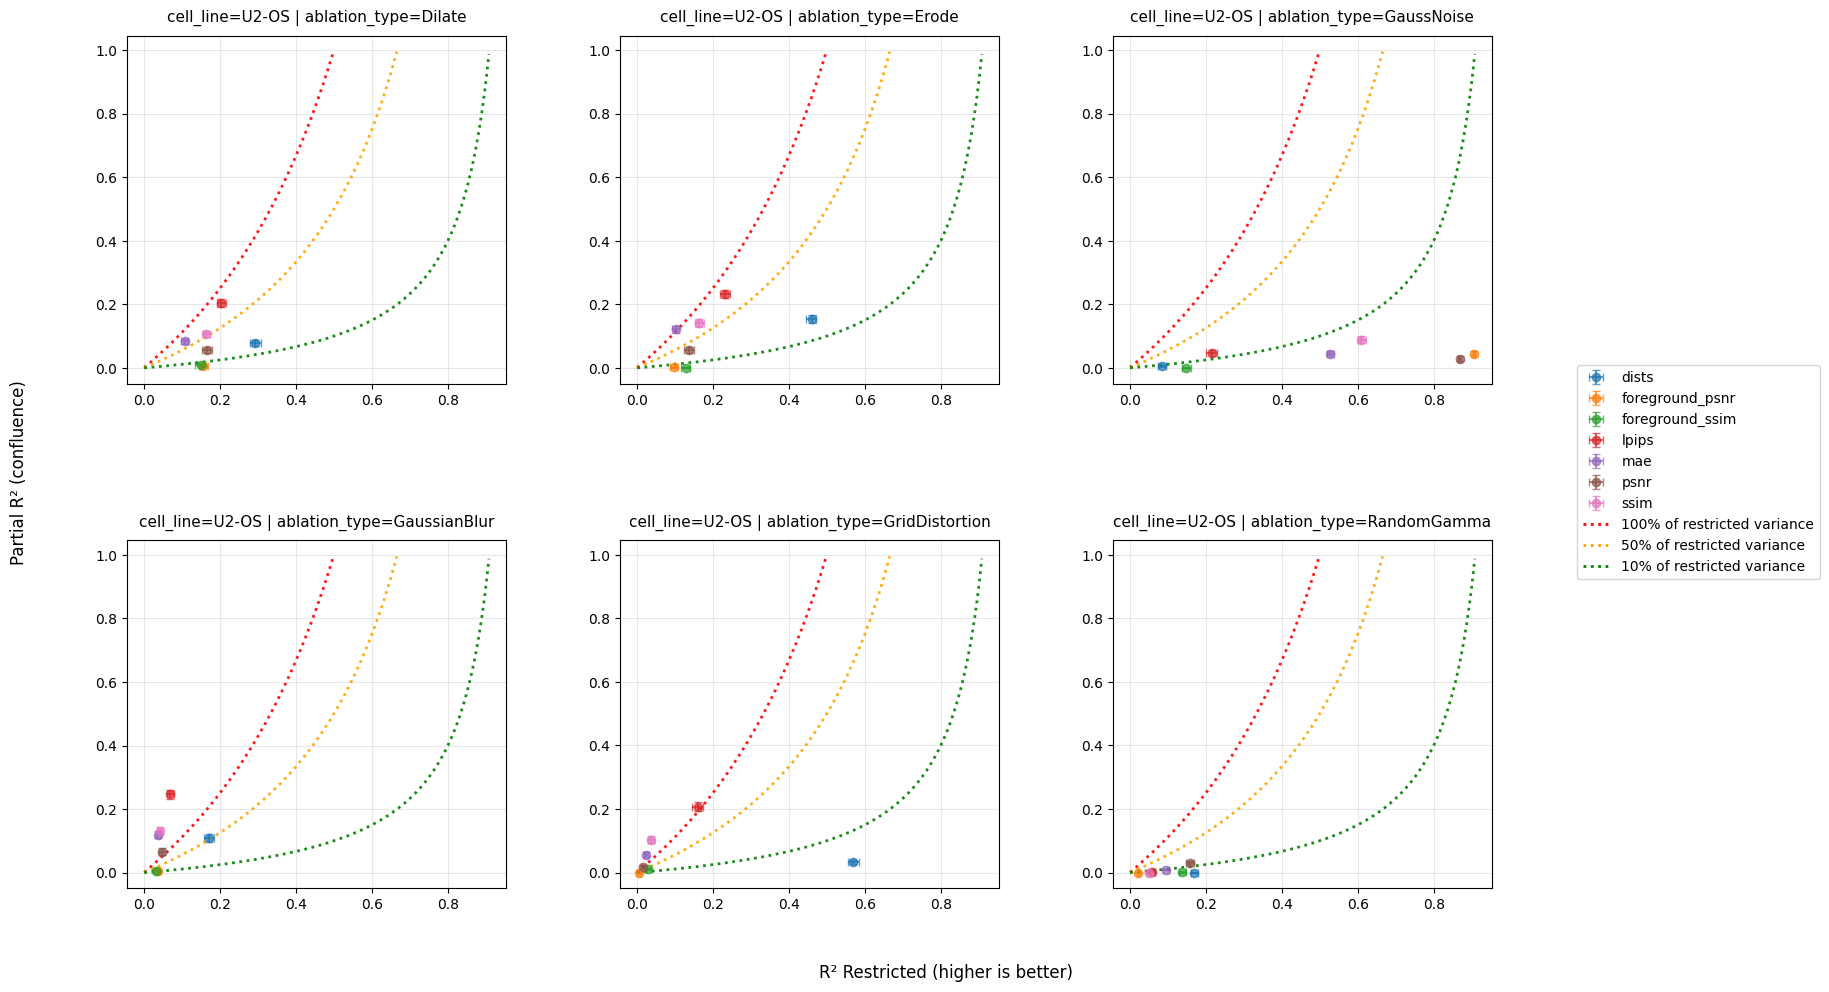

In [14]:
plot_partial_r2_vs_r2(
    boot_res=boot_res,
    panel_cols=["cell_line", "ablation_type"], 
    save_path=pathlib.Path("plots/plate2_u2os_nest_confluence.png"),
    show=True,
    **visualization_config
)

## Regression Analysis 3: Plate confluence=8000 U2-OS cell line, detecting how biased each metric is against plate

In [15]:
# U2-OS across 2 plates but only seeding density 8000 condition
for_regression_u2os_conf8000 = for_regression[
    (for_regression['cell_line'] == 'U2-OS') &
    (for_regression['seeding_density'] == 8000)
].copy()
print(f"Number of samples in U2-OS with seeding density 8000: {len(for_regression_u2os_conf8000)}")

# Encode plate1 vs plate2
for_regression_u2os_conf8000['is_plate2'] = (for_regression_u2os_conf8000['platemap_file'] == 'Assay_Plate2_platemap').astype(int)
for_regression_u2os_conf8000.head()

Number of samples in U2-OS with seeding density 8000: 347424


,created_at,run_id,original_abs_path,original_rel_path,aug_abs_path,aug_rel_path,variant,config_id,params_json,param_fixed,...,Metadata_PositionY,Metadata_PositionZ,Metadata_Row,Metadata_Reimaged,ablation_package,ablation_type,hash,metric_name,metric_value,is_plate2
10086,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.1,5)_8b45fe533dc58654",albumentations:GridDistortion:8b45fe533dc58654,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,-0.000006,13.0,False,albumentations,GridDistortion,8b45fe533dc58654,mae,0.002564,0
10087,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.2,5)_eabce0e6ac52da0e",albumentations:GridDistortion:eabce0e6ac52da0e,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,-0.000006,13.0,False,albumentations,GridDistortion,eabce0e6ac52da0e,mae,0.002125,0
10094,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.1,5)_8b45fe533dc58654",albumentations:GridDistortion:8b45fe533dc58654,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,-0.000006,13.0,False,albumentations,GridDistortion,8b45fe533dc58654,ssim,0.959869,0
10095,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.2,5)_eabce0e6ac52da0e",albumentations:GridDistortion:eabce0e6ac52da0e,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,-0.000006,13.0,False,albumentations,GridDistortion,eabce0e6ac52da0e,ssim,0.970908,0
10102,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.1,5)_8b45fe533dc58654",albumentations:GridDistortion:8b45fe533dc58654,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,-0.000006,13.0,False,albumentations,GridDistortion,8b45fe533dc58654,psnr,46.650364,0


In [16]:
colspec = ColumnSpec(
    group_cols=("metric_name", "cell_line", "ablation_type"),
    x2="is_plate2", # full regression parameters
    x2_categorical=False,
    standardize_cols=("param_values",),
    **regression_config
)

cfg = BootstrapConfig(
    **bootstrap_config
)

boot_res = bootstrap_nested_regression(for_regression_u2os_conf8000, colspec, cfg)
boot_res.to_csv(results_dir / "boot_res_u2os_conf8000_nest_plate.csv", index=False)

Bootstrap groups:   0%|          | 0/42 [00:00<?, ?it/s]

### Visualize

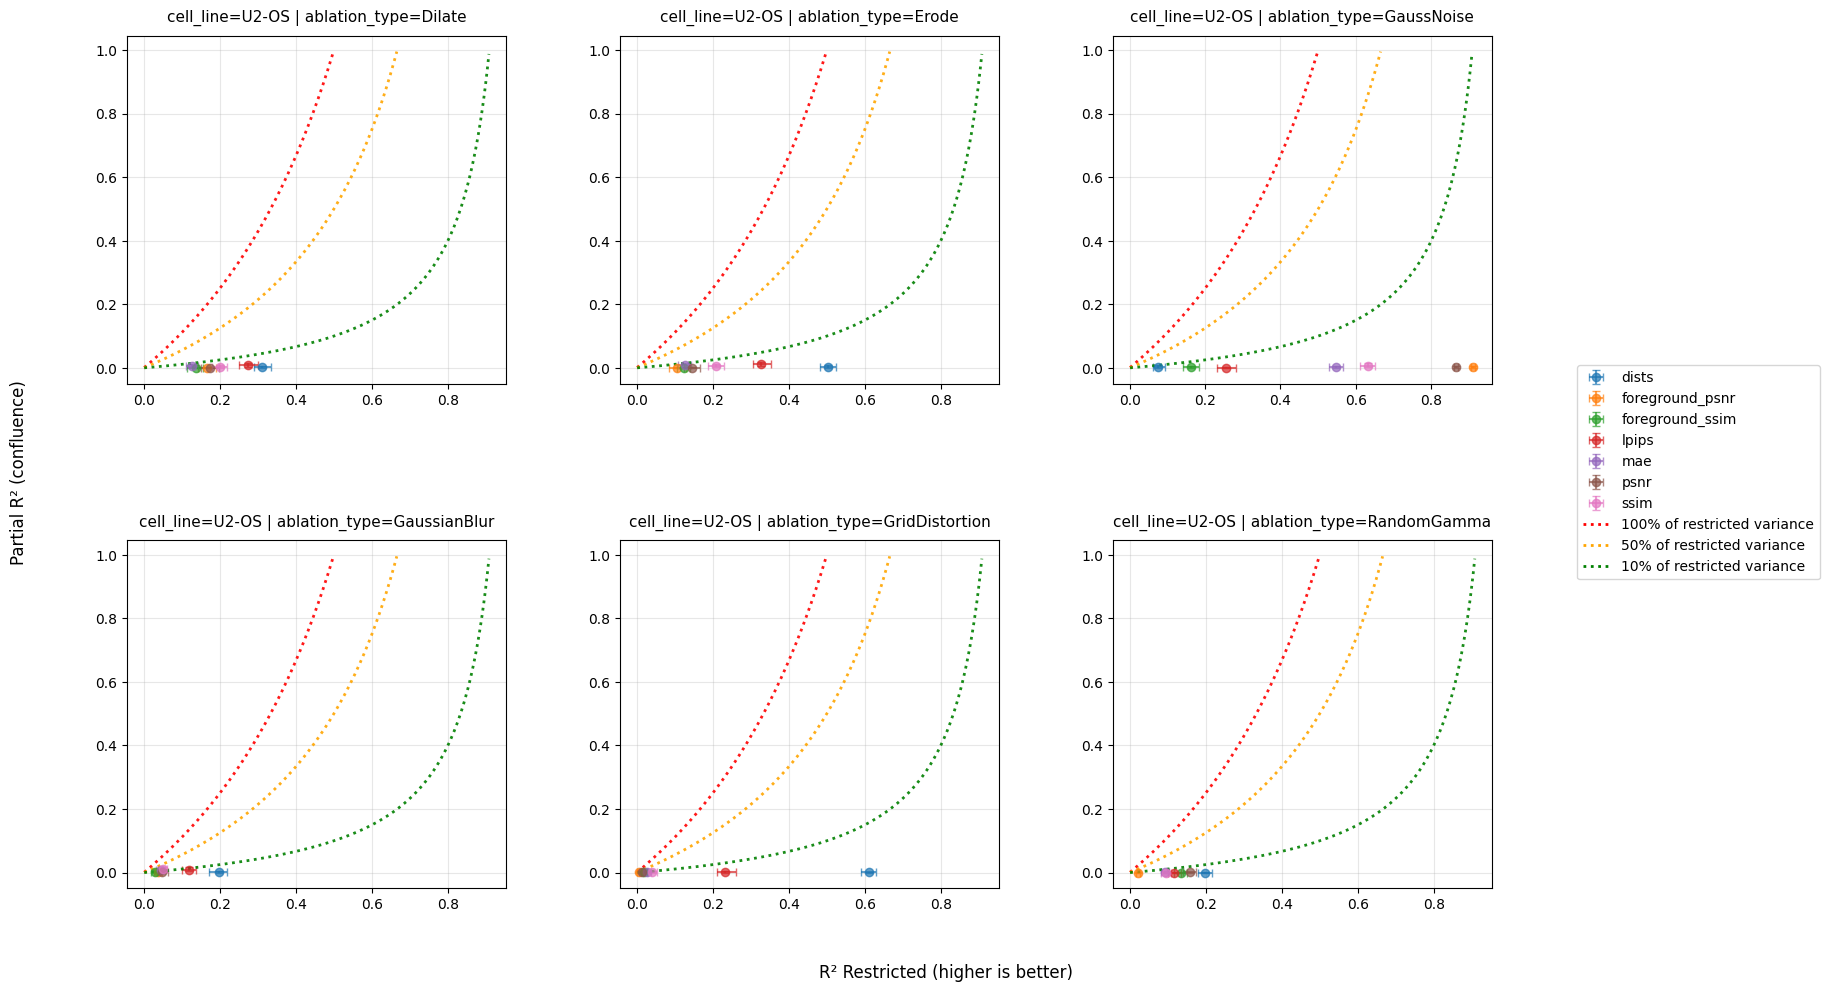

In [17]:
plot_partial_r2_vs_r2(
    boot_res=boot_res,
    panel_cols=["cell_line", "ablation_type"], 
    save_path=pathlib.Path("plots/conf8000_u2os_nest_plate.png"),
    show=True,
    **visualization_config
)

It seems like none of the metrics can pick up (and thus be biased by) any batch effect across plates!

## Regression Analysis 4A: All cell lines with confluence=8000, detecting how biased each metric is against cell lines
This is a lot more samples, expect regression w/th bootstrap to take >15 minutes.

If runtime is a problem tune down `n_boot` and/or `sample_frac` in `BootstrapConfig`

In [18]:
# All cell lines in plate 1 and plate 2 for the cross cell line regression analysis
for_regression_c8000 = for_regression[
    (for_regression['seeding_density'] == 8000)
]
print(f"Number of all confluence 8000 samples: {len(for_regression_c8000)}")
for_regression_c8000.head()

Number of all confluence 8000 samples: 3270960


,created_at,run_id,original_abs_path,original_rel_path,aug_abs_path,aug_rel_path,variant,config_id,params_json,param_fixed,...,Metadata_PositionX,Metadata_PositionY,Metadata_PositionZ,Metadata_Row,Metadata_Reimaged,ablation_package,ablation_type,hash,metric_name,metric_value
10086,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.1,5)_8b45fe533dc58654",albumentations:GridDistortion:8b45fe533dc58654,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,0.0,-0.000006,13.0,False,albumentations,GridDistortion,8b45fe533dc58654,mae,0.002564
10087,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.2,5)_eabce0e6ac52da0e",albumentations:GridDistortion:eabce0e6ac52da0e,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,0.0,-0.000006,13.0,False,albumentations,GridDistortion,eabce0e6ac52da0e,mae,0.002125
10094,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.1,5)_8b45fe533dc58654",albumentations:GridDistortion:8b45fe533dc58654,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,0.0,-0.000006,13.0,False,albumentations,GridDistortion,8b45fe533dc58654,ssim,0.959869
10095,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.2,5)_eabce0e6ac52da0e",albumentations:GridDistortion:eabce0e6ac52da0e,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,0.0,-0.000006,13.0,False,albumentations,GridDistortion,eabce0e6ac52da0e,ssim,0.970908
10102,20260218T201130562139Z,158233ca-0f56-414c-9c0c-1039f01abf46,/mnt/data_nvme1/data/ALSF_pilot_data/SN0313537...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,/mnt/hdd20tb/alsf_ablation/SN0313537/BR0014397...,SN0313537/BR00143976__2024-07-04T16_04_45-Meas...,"xform_abl_distort=(0.1,5)_8b45fe533dc58654",albumentations:GridDistortion:8b45fe533dc58654,"{""backend"":""albumentations"",""transform_name"":""...","[""num_steps""]",...,0.0,0.0,-0.000006,13.0,False,albumentations,GridDistortion,8b45fe533dc58654,psnr,46.650364


In [19]:
colspec = ColumnSpec(
    group_cols=("metric_name", "platemap_file", "ablation_type"),
    x2="cell_line", # categorical var
    x2_categorical=True,
    standardize_cols=("param_values",),
    **regression_config
)

cfg = BootstrapConfig(
    **bootstrap_config
)

boot_res = bootstrap_nested_regression(for_regression_c8000, colspec, cfg)
boot_res.to_csv(results_dir / "boot_res_all_conf8000_nest_cell_line.csv", index=False)

Bootstrap groups:   0%|          | 0/84 [00:00<?, ?it/s]

### Visualize

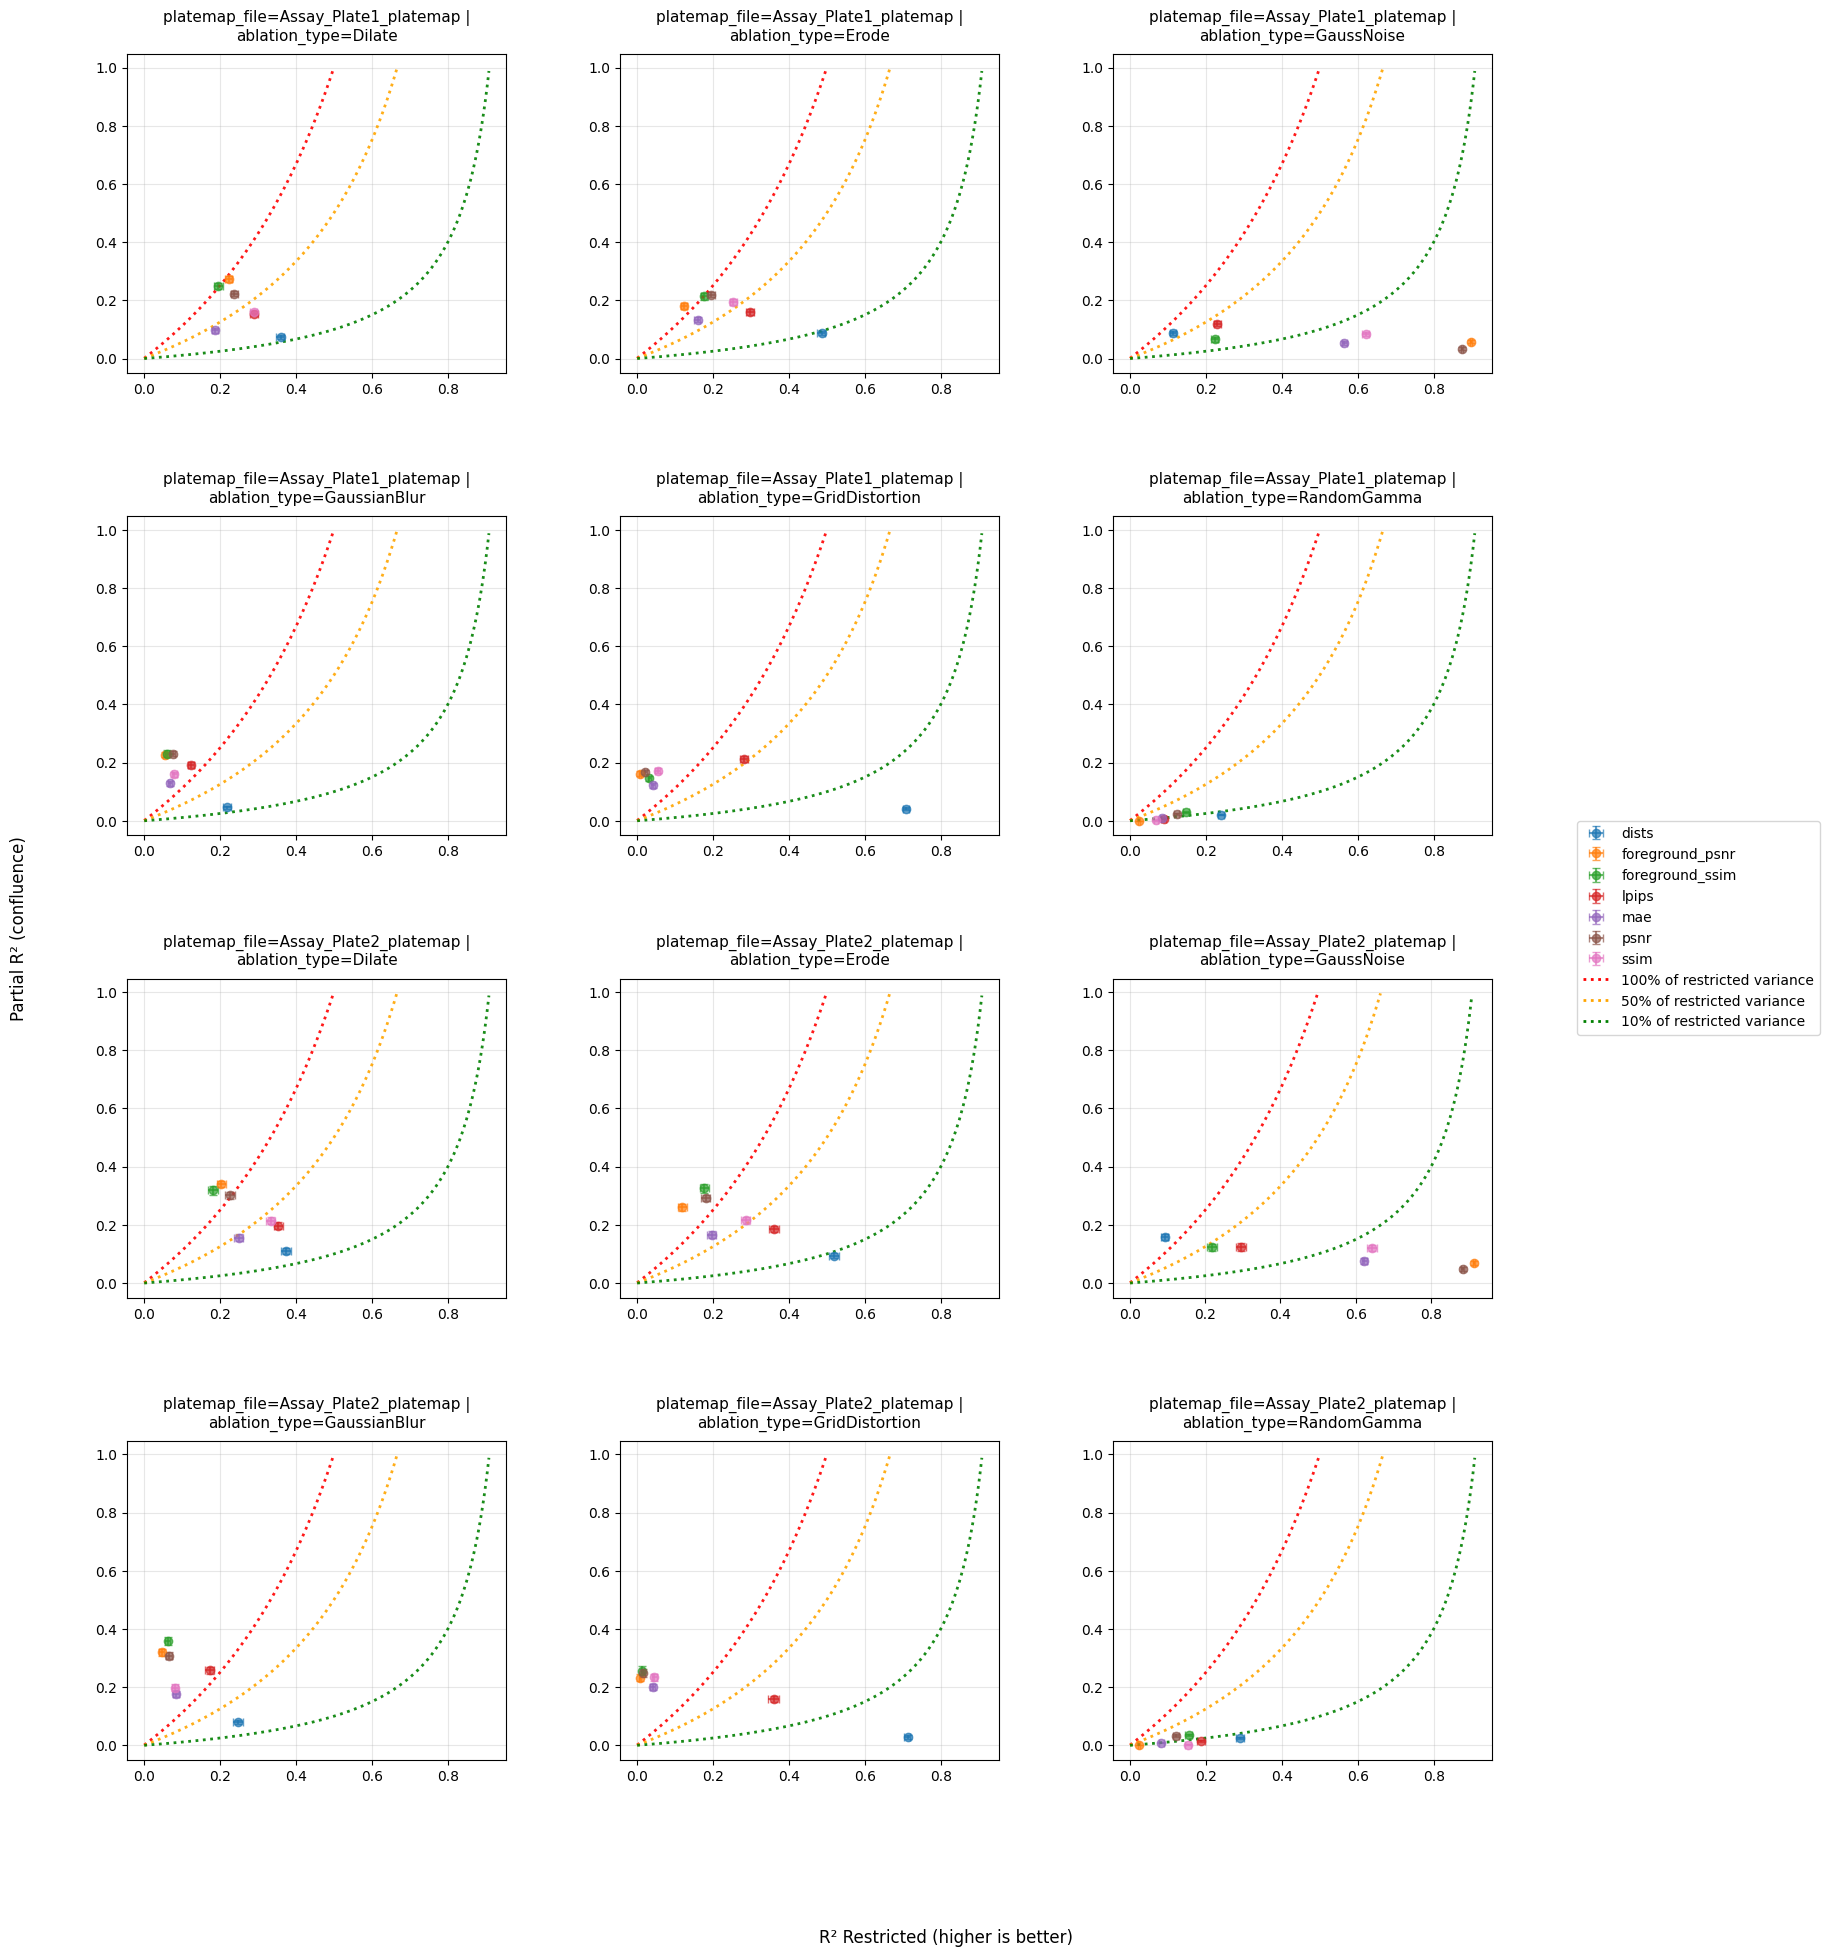

In [20]:
plot_partial_r2_vs_r2(
    boot_res=boot_res,
    panel_cols=["platemap_file", "ablation_type"],
    save_path=pathlib.Path("plots/all_conf8000_nest_cell.png"),
    show=True,
    **visualization_config
)

## Regression Analysis 4B: All cell lines with confluence=8000, detecting how biased each metric is against cell lines
A variant of 4A where the regression are no longer grouped by platemap and all cell lines across two plates are pooled for each regression model fit. 

If runtime is a problem tune down `n_boot` and/or `sample_frac` in `BootstrapConfig`

In [21]:
colspec = ColumnSpec(
    group_cols=("metric_name", "ablation_type"),
    x2="cell_line", # categorical var
    x2_categorical=True,
    standardize_cols=("param_values",),
    **regression_config
)

cfg = BootstrapConfig(
    **bootstrap_config
)

boot_res = bootstrap_nested_regression(for_regression_c8000, colspec, cfg)
boot_res.to_csv(results_dir / "boot_res_all_conf8000_nest_cell_line_pool_plate.csv", index=False)

Bootstrap groups:   0%|          | 0/42 [00:00<?, ?it/s]

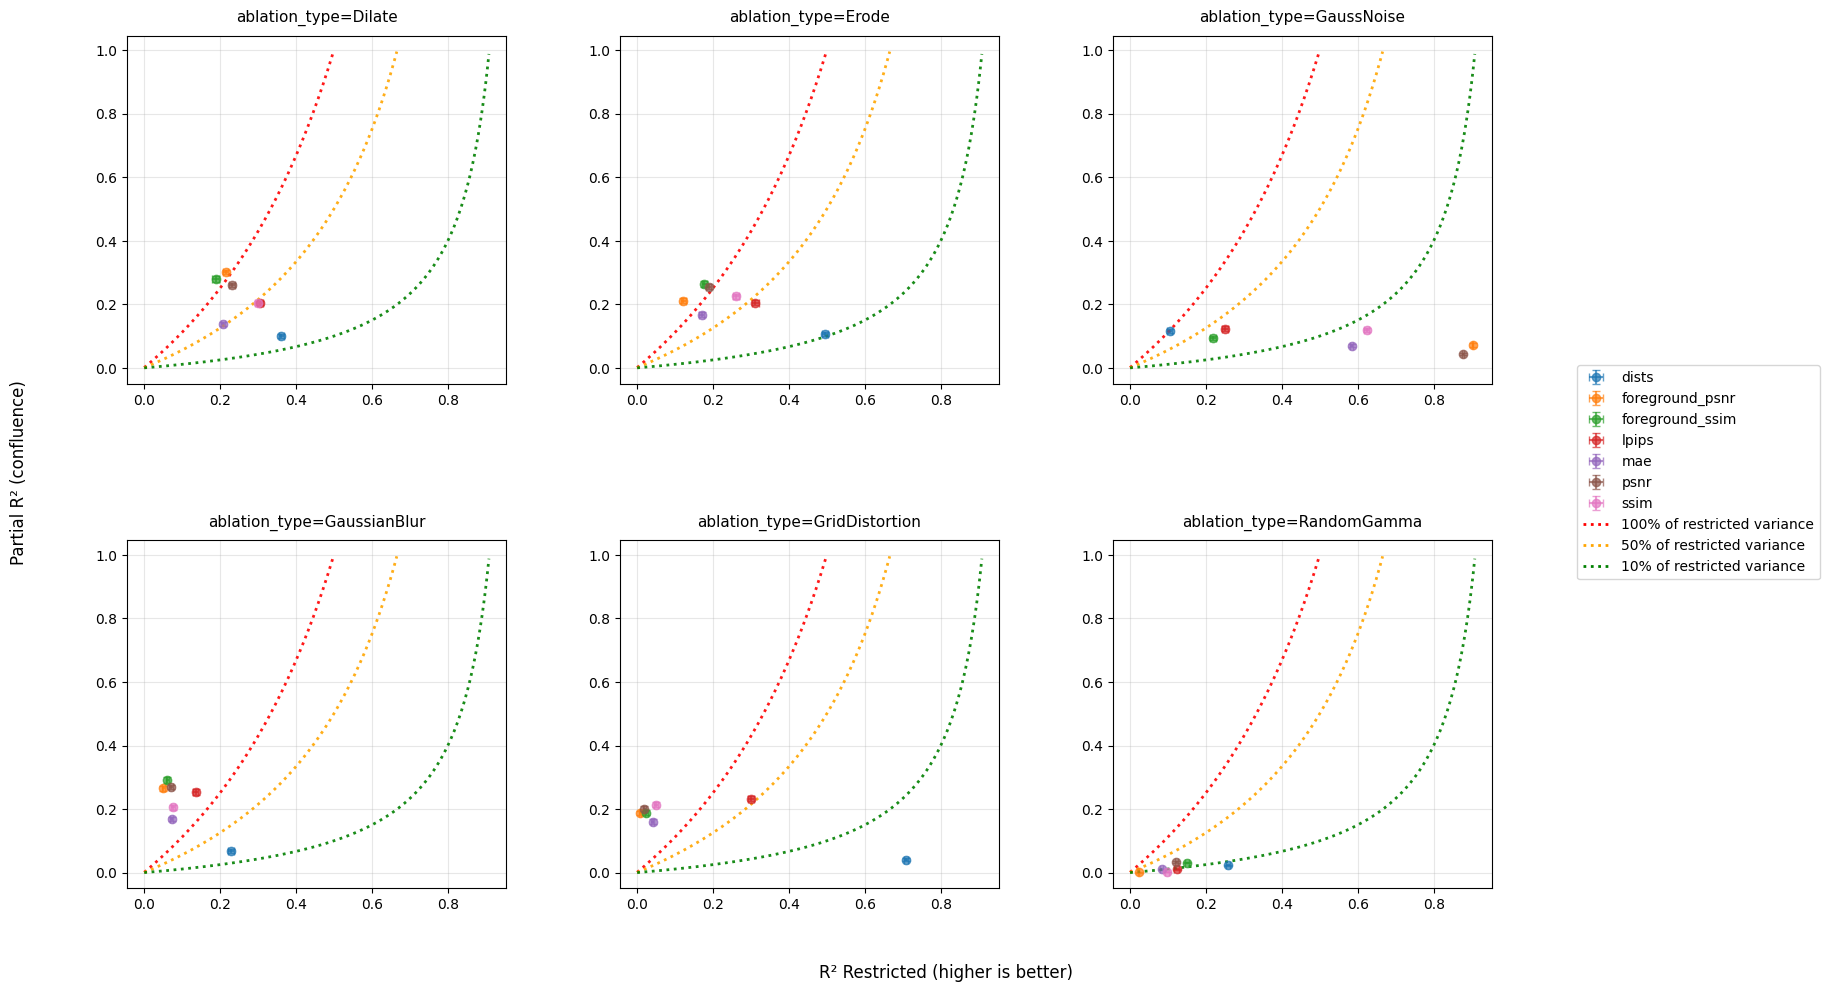

In [22]:
plot_partial_r2_vs_r2(
    boot_res=boot_res,
    panel_cols=["ablation_type"],
    save_path=pathlib.Path("plots/all_conf8000_nest_cell_pool_plate.png"),
    show=True,
    **visualization_config
)